## Experiment Tutorial: Two Qubits

In [1]:
# Import required libraries
import numpy as np
import optax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from qsopt import (
    ExperimentalParameters,
    PhysicalConstants,
    SystemDimensions,
    MeasurementProtocol,
    InteractionType,
    QubitInteraction,
    InitialStateConfig,
    InitialStateType,
    NoiseConfiguration,
    QuantumCircuit,
    create_ry_circuit,
    Experiment,
    DetectionMetric,
    RYGate,
    CNOTGate,
)

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

## 1. Setup Experimental Parameters

In [2]:
# Define experimental parameters using nested configuration objects
inverse_pulse_width = 1
gm = 15 * inverse_pulse_width

interaction = QubitInteraction(
    qubit_indices=(0, 1),
    interaction_type=InteractionType.XX,
    chi=0.1
)

physical_constants = PhysicalConstants(
    n_qubits=2,
    chi=list(np.array([2.0, 2.0])*gm),
    photon_cavity_coupling=gm,
    inverse_pulse_width=inverse_pulse_width,
    qubit_interactions=[interaction]
)

system_dims = SystemDimensions(
    field_levels=2,
    cavity_levels=2,
    qubit_levels=[2, 2]
)

measurement = MeasurementProtocol(
    measurement_times=list(np.array([-5.0, 5.0])/inverse_pulse_width) 
)

initial_state = InitialStateConfig(state_type=InitialStateType.SINGLE_PHOTON)

noise_config = NoiseConfiguration(
    depolarizing=0.01,
    dephasing=0.01,
    relaxation=0.01,
)

exp_params = ExperimentalParameters(
    physical_constants=physical_constants,
    system_dims=system_dims,
    measurement=measurement,
    initial_state=initial_state,
    noise_config=noise_config
)

print(exp_params)

SYSTEM DIMENSIONS
  Number of qubits:          2
  Cavity levels:             2
  Qubit levels:         [2, 2]
  Field levels:              2
  Total dimension:          16
PHYSICAL CONSTANTS
  Chi:                  [30.0, 30.0]
  Photon cavity coupling: 15.0000
  Inverse pulse width:    1.0000
  Qubit interactions:   1 interaction(s)
    [0] Qubits (0, 1): sx-sx, χ=0.1000
MEASUREMENT PROTOCOL
  Mode:                 Explicit list
  Number of measurements:      2
  Measurement times:    [-5.0, 5.0]
INITIAL STATE
  Type:                 single_photon
NOISE MODEL
  Depolarizing rate:    [0.01, 0.01]
  Dephasing rate:       [0.01, 0.01]
  Relaxation rate:      [0.01, 0.01]
  Custom operators:     None
SYSTEM STATUS
  Configuration:        VALID


## 2. Setup Trainable Parameters

For two-qubit experiments, we need 4 rotation angles:
- θ1_q1, θ2_q1: Rotation angles for qubit 1
- θ1_q2, θ2_q2: Rotation angles for qubit 2

In [3]:
# Create Circuit with 4 rotation angles
initial_circuit = create_ry_circuit(n_qubits=2,
        #theta_values= [0, np.pi/2])
        theta_values=np.pi/2)
final_circuit = create_ry_circuit(n_qubits=2,
        #theta_values= [0, -np.pi/2])
        theta_values=-np.pi/2)
#final_circuit.add_entangling_layer(CNOT, 'circular')

#By default if no detection metric is used, the optimization maximizes the detection measure `1 - P(00)` (any outcome except ground state).
detection_metric = DetectionMetric(n_qubits=2, 
                                   detection_criterion = 'max computational distance', 
                                   detection_param=(4,2))

print(f'Initial circuit:\n{initial_circuit}\n')
print(f'Final circuit:\n{final_circuit}')

print(f'\n{detection_metric}')

Initial circuit:
QuantumCircuit(2 qubits, 2 gates)
  0: RY[0](param=1.571)
  1: RY[1](param=1.571)

Final circuit:
QuantumCircuit(2 qubits, 2 gates)
  0: RY[0](param=-1.571)
  1: RY[1](param=-1.571)


DetectionMetric: max computational distance with computational distance
detection criterion:
  'max computational distance'
metric:
  'computational distance'
batching logic:
  'max computational distance batching'
multiple measurement logic:
  'list aggregation'



## 3. Create Two-Qubit Experiment

Initialize the experiment with our parameters. This will:
- Generate operators for the 4-subsystem composite space
- Build the time-dependent Hamiltonian
- Cache initial state and projectors

In [4]:
experiment = Experiment(exp_params, initial_circuit, final_circuit, detection_metric)

## 4. Run Basic Simulation

In [5]:
# Run simulation with zero rotations
callback = experiment.run_simulation(batch_size=1, measurement_times=[-5,5], debug=False, states_probabilities=True)

print(callback)

MODE: Single Simulation
  Current Parameters:
     Initial circuit:
        param_0: 1.570796 rad (90.00°)
        param_1: 1.570796 rad (90.00°)
     Final circuit:
        param_0: -1.570796 rad (-90.00°)
        param_1: -1.570796 rad (-90.00°)
  Detection Measures:
     With photon:    0.000000
     Without photon: 0.097932
     Metric:            -0.097932
  State Probabilities:
     With photon:
        00: 0.035030
        01: 0.140031
        10: 0.140031
        11: 0.684907
     Without photon:
        00: 0.706933
        01: 0.133860
        10: 0.133860
        11: 0.025347
  Detection Protocol:
     Interaction states: ['01', '10', '11']
     Non-interaction states: ['00']
  Confusion Matrix:
     --------------------
     True Positive:  0.964970
     False Negative: 0.035030
     --------------------
     True Negative:  0.706933
     False Positive: 0.293067
     --------------------


## 5. Optimize Rotation Angles

Now let's optimize the four rotation angles to maximize the metric defined by the DetectionMetric.


In [7]:
# Optimize
callback_opt = experiment.optimize_rotations(
    num_steps=500,
    batch_size=1,
    tolerance=1e-8,
    verbose=True,
    verbose_step=50,
    initial_values=[np.pi/2, np.pi/2, -np.pi/2, -np.pi/2],
    renormalize_grad=False,
    optimizer=optax.sgd(learning_rate=0.1),
    noisy_training=True
)


Configuration:
    Max iterations: 500
    Batch size: 1
    Convergence tolerance: 1.00e-08
    Detection metric: max computational distance with computational distance
    Trainable parameters: 4 (2 initial circuit + 2 final circuit)
    Initial parameter values:
        param0.  setup_RY[0]  = 1.571  rad (90.0°)
        param1.  setup_RY[1]  = 1.571  rad (90.0°)
        param2.  reset_RY[0]  = -1.571 rad (-90.0°)
        param3.  reset_RY[1]  = -1.571 rad (-90.0°)
Step  setup0_RY[0]   setup1_RY[1]   reset0_RY[0]   reset1_RY[1]   Metric      Grad Norm   Time
---------------------------------------------------------------------------------------------------
0     1.570796       1.570796       -1.570796      -1.570796      -0.097932   1.06e-02    00h00m10s
1     1.570085       1.570143       -1.571045      -1.570974      -0.097922   1.04e-02    00h00m11s
2     1.569412       1.569440       -1.571277      -1.571120      -0.097911   1.03e-02    00h00m11s
50    1.545902       1.544842    

In [ ]:
# Create entangled input ciruit with 6 rotation angles
initial_circuit_ent = create_ry_circuit(n_qubits=2,
        theta_values=0)
initial_circuit_ent.add_entangling_layer(CNOTGate, pattern='circular')
initial_circuit_ent.add_layer(RYGate, parameters=np.pi/2)

experiment_10 = Experiment(exp_params, initial_circuit_ent, final_circuit, detection_metric)

callback_opt_ent = experiment_10.optimize_rotations(
    num_steps=500,
    batch_size=1,
    tolerance=1e-8,
    verbose=True,
    verbose_step=50,
    renormalize_grad=False,
    optimizer=optax.sgd(learning_rate=0.1)
)

Configuration:
    Max iterations: 500
    Batch size: 1
    Convergence tolerance: 1.00e-08
    Detection metric: max computational distance with computational distance
    Trainable parameters: 6 (4 initial circuit + 2 final circuit)
    Initial parameter values:
        param0.  setup_RY[0]  = 0.000  rad (0.0°)
        param1.  setup_RY[1]  = 0.000  rad (0.0°)
        param2.  setup_RY[0]  = 1.571  rad (90.0°)
        param3.  setup_RY[1]  = 1.571  rad (90.0°)
        param4.  reset_RY[0]  = -1.580 rad (-90.5°)
        param5.  reset_RY[1]  = -1.580 rad (-90.5°)
Step  setup0_RY[0]   setup1_RY[1]   setup2_RY[0]   setup3_RY[1]   reset0_RY[0]   reset1_RY[1]   Metric      Grad Norm   Time
---------------------------------------------------------------------------------------------------------------------------------
0     0.000000       0.000000       1.570796       1.570796       -1.580074      -1.580074      -0.097904   1.29e-02    00h00m10s
1     -0.000698      0.000425       1.57010

In [ ]:
print(callback_opt)

MODE: Optimization
     Total iterations: 500
     Best epoch:        500
     Converged: False
     Final gradient norm: 8.051456e-06
  Best Parameters:
     Initial circuit:
        param_0: 1.522986 rad (87.26°)
        param_1: 1.522986 rad (87.26°)
     Final circuit:
        param_0: -1.580074 rad (-90.53°)
        param_1: -1.580074 rad (-90.53°)
  Detection Measures:
     With photon:    0.000000
     Without photon: 0.097568
     Metric:            -0.097568
  State Probabilities:
     With photon:
        00: 0.034656
        01: 0.138217
        10: 0.138217
        11: 0.688910
     Without photon:
        00: 0.705263
        01: 0.134536
        10: 0.134536
        11: 0.025664
  Detection Protocol:
     Interaction states: ['01', '10', '11']
     Non-interaction states: ['00']
  Confusion Matrix:
     --------------------
     True Positive:  0.965344
     False Negative: 0.034656
     --------------------
     True Negative:  0.705263
     False Positive: 0.294737
    

In [ ]:
print(callback_opt_ent)

MODE: Optimization
     Total iterations: 500
     Best epoch:        500
     Converged: False
     Final gradient norm: 7.875889e-06
  Best Parameters:
     Initial circuit:
        param_0: -0.023674 rad (-1.36°)
        param_1: 0.004442 rad (0.25°)
        param_2: 1.523808 rad (87.31°)
        param_3: 1.547326 rad (88.66°)
     Final circuit:
        param_0: -1.580432 rad (-90.55°)
        param_1: -1.580398 rad (-90.55°)
  Detection Measures:
     With photon:    0.000000
     Without photon: 0.097563
     Metric:            -0.097563
  State Probabilities:
     With photon:
        00: 0.034633
        01: 0.138239
        10: 0.138241
        11: 0.688886
     Without photon:
        00: 0.705247
        01: 0.134540
        10: 0.134541
        11: 0.025672
  Detection Protocol:
     Interaction states: ['01', '10', '11']
     Non-interaction states: ['00']
  Confusion Matrix:
     --------------------
     True Positive:  0.965367
     False Negative: 0.034633
     -------

### Visualize Optimization Progress

Let's plot how the metric evolved during optimization:


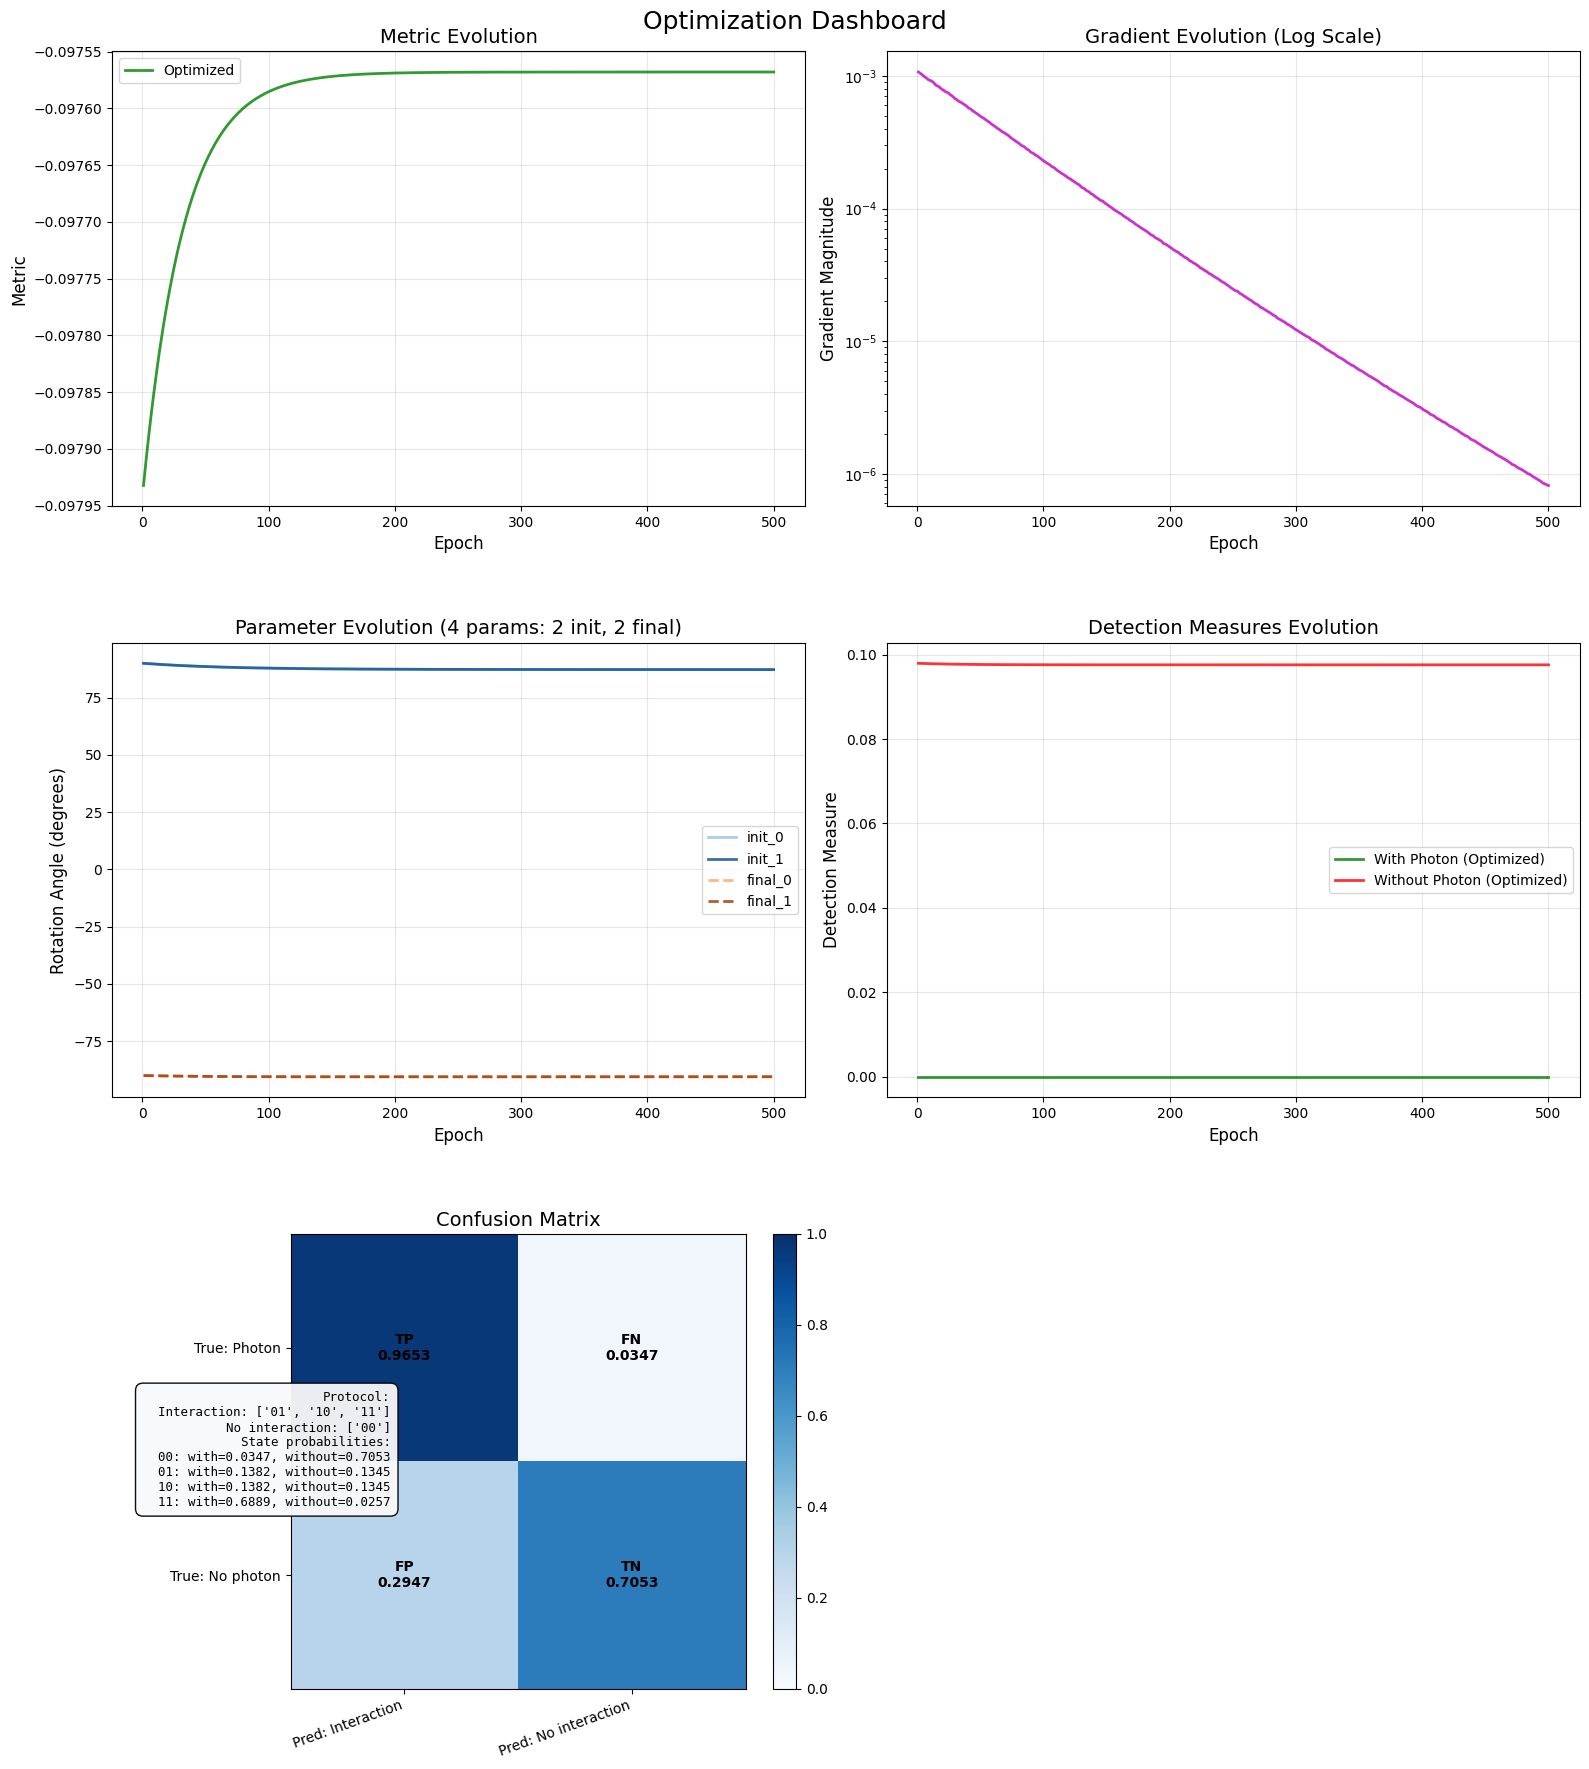

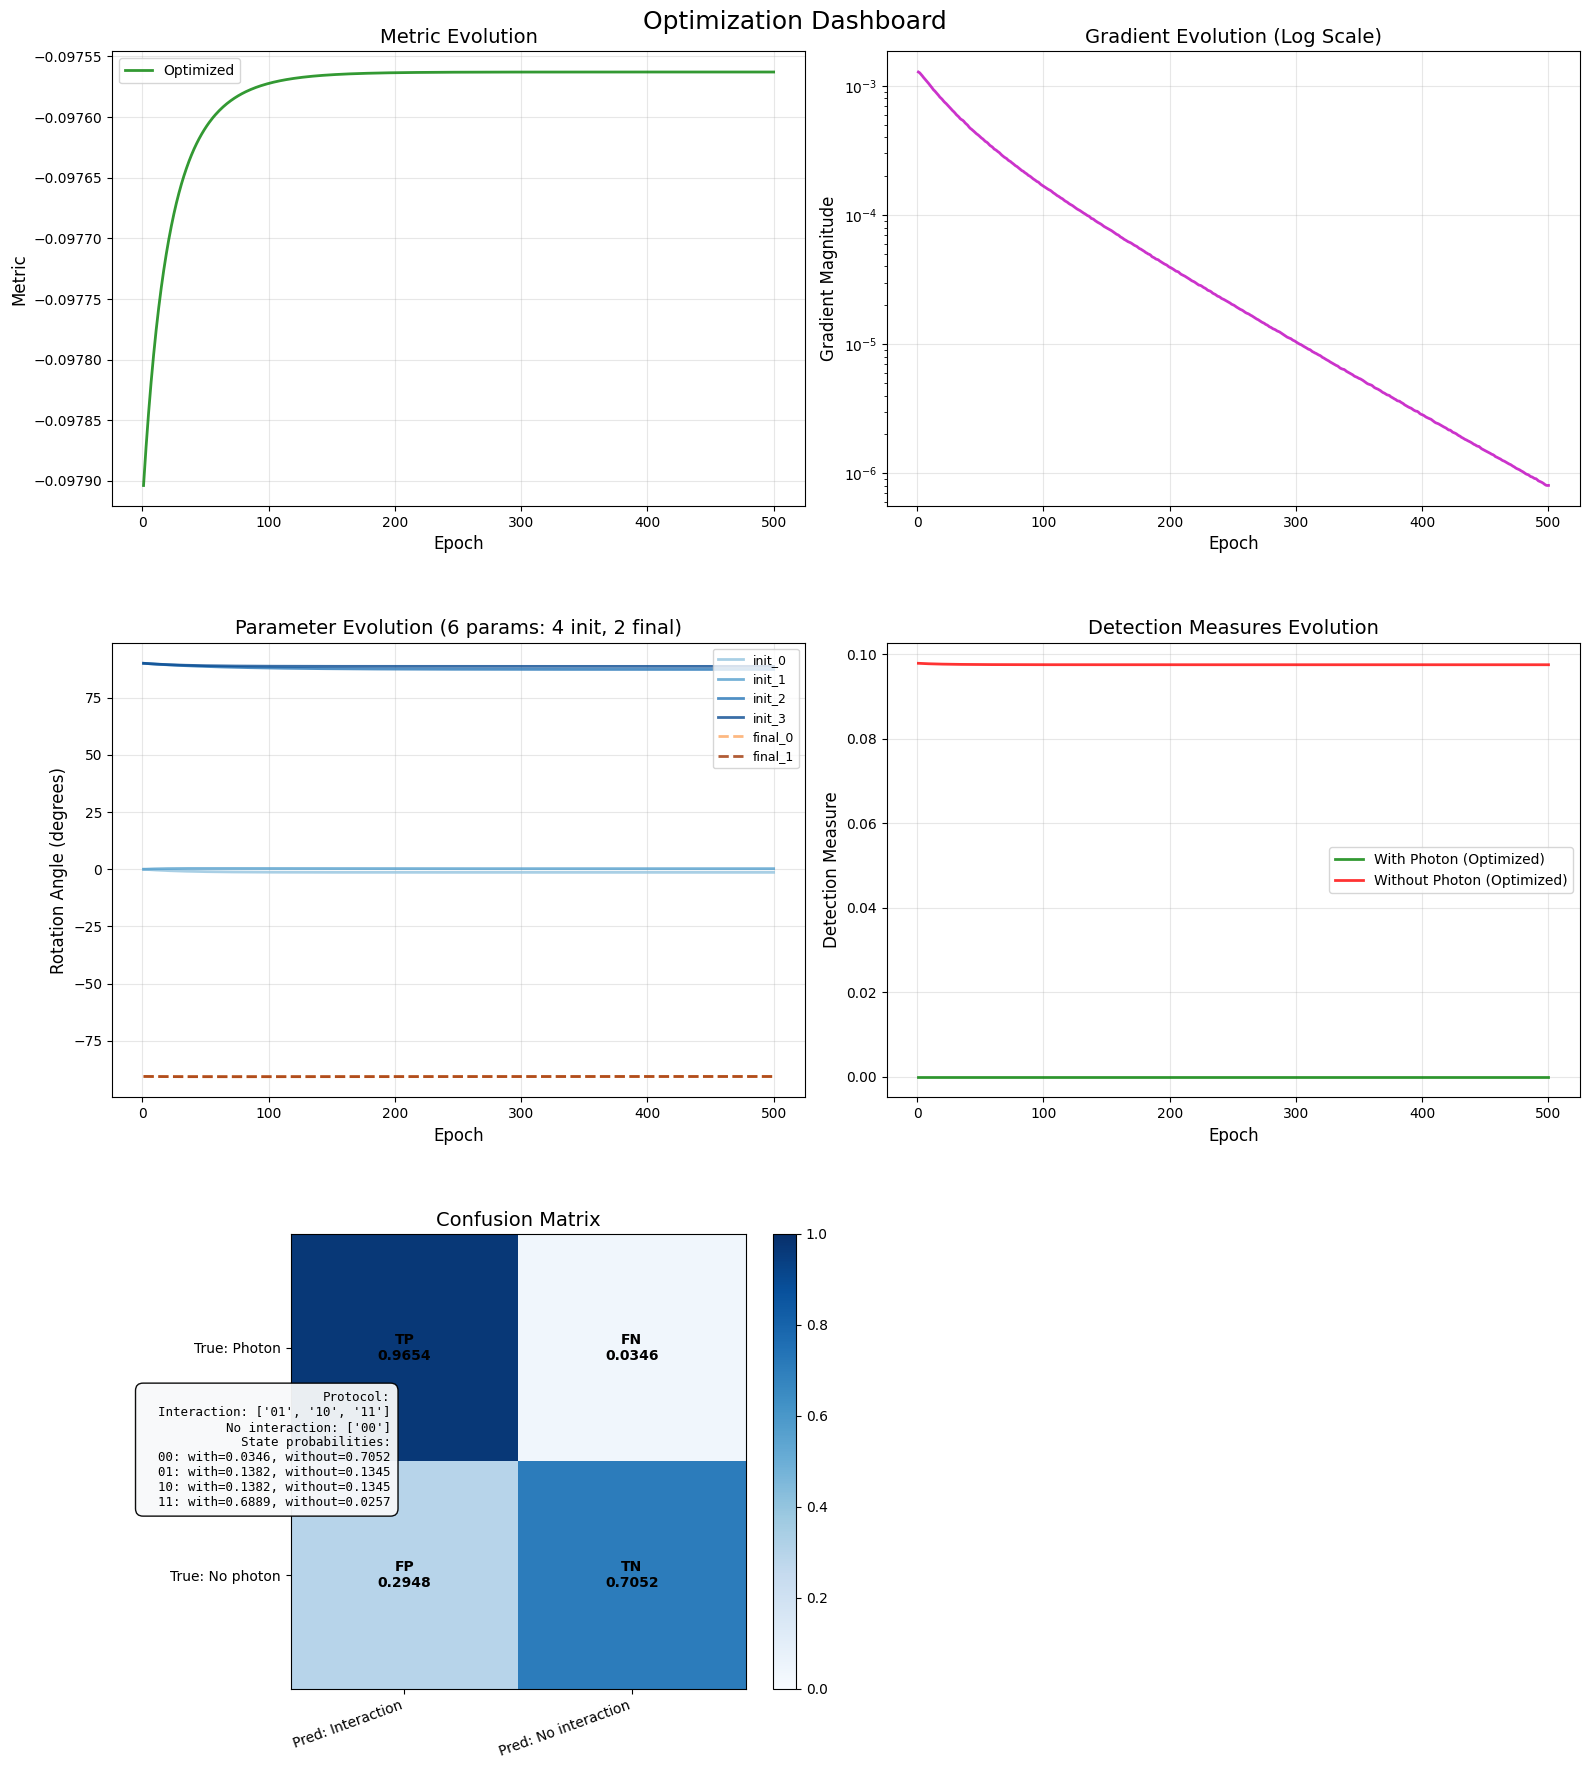

In [ ]:
from qsopt.utils.visualization import plot_optimization_dashboard

# Create comprehensive dashboard showing all optimization metrics
fig = plot_optimization_dashboard(
    callback_opt,
    show_metric=True,
    show_gradients=True,
    show_parameters=True,
    show_trajectory=False,
    show_detection_measures=True,
    show_confusion_matrix_summary=True,
)
plt.show()

# Create comprehensive dashboard showing all optimization metrics
fig = plot_optimization_dashboard(
    callback_opt_ent,
    show_metric=True,
    show_gradients=True,
    show_parameters=True,
    show_trajectory=False,
    show_detection_measures=True,
    show_confusion_matrix_summary=True,
)
plt.show()
